# Explaining a Neural Network on MNIST

DenseNet121 classifies handwritten digits at 97.8%, and nothing about how it
gets there is visible from its weights. This notebook applies the five XAI
techniques the brief asks for, plus plain saliency, to find out where it looks
and why it fails on the cases it fails.

The order follows the consulting pipeline rather than the brief:

1. a **glass box** first — logistic regression, fully readable, as the bar the
   black box has to beat
2. the **black box** — DenseNet121 fine-tuned, used only because the accuracy
   gain justifies it
3. **saliency maps** — Grad-CAM, Occlusion, Integrated Gradients, SHAP, LIME,
   compared on correct and wrong predictions
4. the two models **side by side**, to show what transparency was traded away

In [1]:
!pip install -q captum lime

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

# dataset and black box model
from torchvision.datasets import MNIST
from torchvision import transforms
from torchvision.models import densenet121, DenseNet121_Weights

# glass box baseline and metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# XAI: attribution and saliency methods
from captum.attr import (
    Saliency,
    IntegratedGradients,
    Occlusion,
    LayerGradCam,
    GradientShap,
)
from lime.lime_image import LimeImageExplainer

import warnings
warnings.filterwarnings("ignore")


SEED = 0

np.random.seed(SEED)
torch.manual_seed(SEED)


# cuDNN picks non-deterministic convolution algorithms by default:
# two runs of the same backward pass can differ, and so can the maps
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cuda


## 1. Dataset

MNIST comes from two NIST collections: the training digits were written by Census
Bureau employees, the test digits by American high school students. The two
groups write differently, which is why the original split is kept as it is rather
than reshuffled.

Each digit was size-normalised to a 20x20 box and centred by centre of mass in a
28x28 frame: 60.000 training and 10.000 test images, greyscale, ten balanced
classes.

DenseNet121 expects 3-channel images of at least 224x224, so the digits are
resized and replicated across channels. The glass box baseline instead works on
the raw 28x28 pixels.

In [3]:
# DenseNet121 was trained on ImageNet: 3 channels, 224x224, ImageNet statistics
densenet_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [4]:
train_set = MNIST(root="./data", train=True, download=True, transform=densenet_transform)
test_set = MNIST(root="./data", train=False, download=True, transform=densenet_transform)

print(f"{'train:':<10}{len(train_set):>7}")
print(f"{'test:':<10}{len(test_set):>7}")
print(f"{'classes:':<10}{len(train_set.classes):>7}")

train:      60000
test:       10000
classes:       10


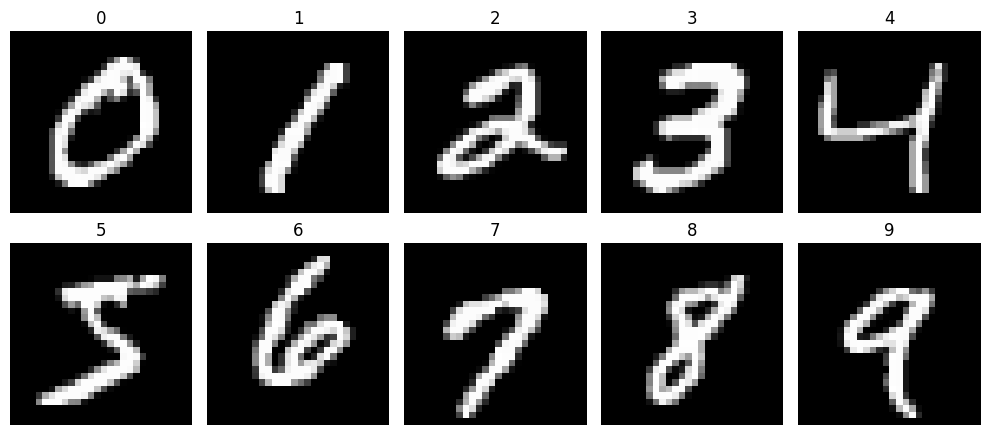

In [5]:
# the raw images, before any transform
figure, axes = plt.subplots(2, 5, figsize=(10, 4.5))

for digit, ax in enumerate(axes.flat):
    index = (train_set.targets == digit).nonzero()[0].item()
    ax.imshow(train_set.data[index], cmap="gray")
    ax.set_title(str(digit))
    ax.axis("off")

plt.tight_layout()
plt.show()

## 2. Glass Box Baseline

Before reaching for a black box, training a model that needs no explainer at all.
Logistic regression on the raw pixels is fully described by its coefficients:
ten weight vectors, one per digit, that can be read directly.

This also sets the bar the black box has to beat, in numbers rather than by
assumption.

In [6]:
# logistic regression works on the raw 28x28 pixels, flattened and scaled to [0, 1]
X_train = train_set.data.numpy().reshape(len(train_set), -1) / 255.0
y_train = train_set.targets.numpy()

X_test = test_set.data.numpy().reshape(len(test_set), -1) / 255.0
y_test = test_set.targets.numpy()

print(f"{'X_train:':<12}{str(X_train.shape):>14}")
print(f"{'X_test:':<12}{str(X_test.shape):>14}")

X_train:      (60000, 784)
X_test:       (10000, 784)


In [7]:
# C is the inverse of the regularization strength: lower C, smoother coefficients
glass_box = LogisticRegression(max_iter=200, C=0.01, random_state=SEED)
glass_box.fit(X_train, y_train)

y_pred_glass = glass_box.predict(X_test)
accuracy_glass = accuracy_score(y_test, y_pred_glass)

print(f"{'glass box accuracy:':<24}{accuracy_glass:>8.4f}")

glass box accuracy:       0.9189


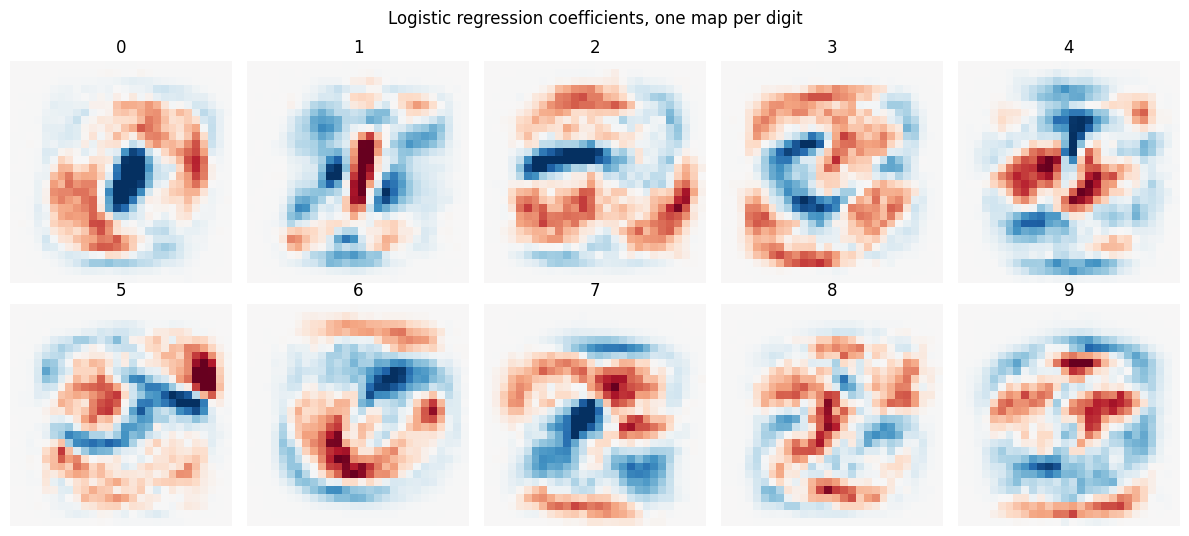

In [8]:
# one coefficient vector per class, reshaped to the original image size
scale = np.percentile(np.abs(glass_box.coef_), 99)  # clip outliers, keep the structure visible

figure, axes = plt.subplots(2, 5, figsize=(12, 5.5))

for digit, ax in enumerate(axes.flat):
    ax.imshow(glass_box.coef_[digit].reshape(28, 28),
              cmap="RdBu_r", vmin=-scale, vmax=scale)
    ax.set_title(str(digit))
    ax.axis("off")

figure.suptitle("Logistic regression coefficients, one map per digit")
plt.tight_layout()
plt.show()

- Accuracy 91.89%, against 92.65% with the default regularization: the templates only appear once L2 is strong
enough to spread the weight over regions instead of single pixels.

- The maps read directly. Zero has a red ring with a blue centre, where ink must
not be. One has a red vertical band flanked by blue. Two has the positive
diagonal at the bottom. The model has learnt where ink should and should not be,
and that is the whole of it — no explainer needed.

Regularization here is a readability choice as much as a performance one.

## 3. Black Box

DenseNet121 pretrained on ImageNet, with the classifier replaced by a 10-class
head. Only the last dense block and the head are fine-tuned: the earlier
features are generic enough for digits.

The black box is only worth using if it beats 91.89% by enough to justify losing
the transparency of the glass box.

In [9]:
def build_black_box():
    """DenseNet121 with ImageNet weights, last dense block and head trainable."""
    torch.manual_seed(SEED)
    model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)

    for parameter in model.parameters():
        parameter.requires_grad = False
    for parameter in model.features.denseblock4.parameters():
        parameter.requires_grad = True

    model.classifier = nn.Linear(model.classifier.in_features, 10)
    return model.to(DEVICE)


black_box = build_black_box()
trainable = sum(p.numel() for p in black_box.parameters() if p.requires_grad)
print(f"{'trainable parameters:':<24}{trainable:>10,}")

trainable parameters:    2,168,330


In [10]:
# 10.000 images are enough to fine-tune the head: the full set would take far longer
generator = torch.Generator().manual_seed(SEED)
train_indices = torch.randperm(len(train_set), generator=generator)[:10_000]
train_subset = Subset(train_set, train_indices.tolist())

print(f"{'training images:':<20}{len(train_subset):>7}")

training images:      10000


In [11]:
def train_black_box(model, dataset, epochs=2, batch_size=64, lr=1e-4):
    generator = torch.Generator().manual_seed(SEED)  # fixed batch order
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                        num_workers=0, generator=generator)
    criterion = nn.CrossEntropyLoss()  # expects raw logits
    optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)

    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in tqdm(loader, desc=f"epoch {epoch + 1}/{epochs}", leave=False):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        print(f"epoch {epoch + 1:<3} loss: {running_loss / len(dataset):.4f}")
    return model


black_box = train_black_box(black_box, train_subset)

epoch 1/2:   0%|          | 0/157 [00:00<?, ?it/s]

epoch 1   loss: 0.6371


epoch 2/2:   0%|          | 0/157 [00:00<?, ?it/s]

epoch 2   loss: 0.1223


In [12]:
@torch.no_grad()
def predict_black_box(model, dataset, batch_size=128):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    model.eval()

    all_predictions, all_confidences = [], []
    for images, _ in tqdm(loader, desc="predicting"):
        probabilities = model(images.to(DEVICE)).softmax(dim=1)
        confidence, prediction = probabilities.max(dim=1)
        all_predictions.append(prediction.cpu())
        all_confidences.append(confidence.cpu())
    return torch.cat(all_predictions).numpy(), torch.cat(all_confidences).numpy()


y_pred_black, confidence_black = predict_black_box(black_box, test_set)
accuracy_black = accuracy_score(y_test, y_pred_black)

print(f"{'black box accuracy:':<24}{accuracy_black:>8.4f}")
print(f"{'glass box accuracy:':<24}{accuracy_glass:>8.4f}")

predicting:   0%|          | 0/79 [00:00<?, ?it/s]

black box accuracy:       0.9777
glass box accuracy:       0.9189


Black box 97.79% against 91.89% for the glass box: 5.9 points. That is the
number that justifies giving up transparency — without it, the linear model
would be the right choice.

221 test images are still misclassified. Those are what the rest of the notebook
is about.

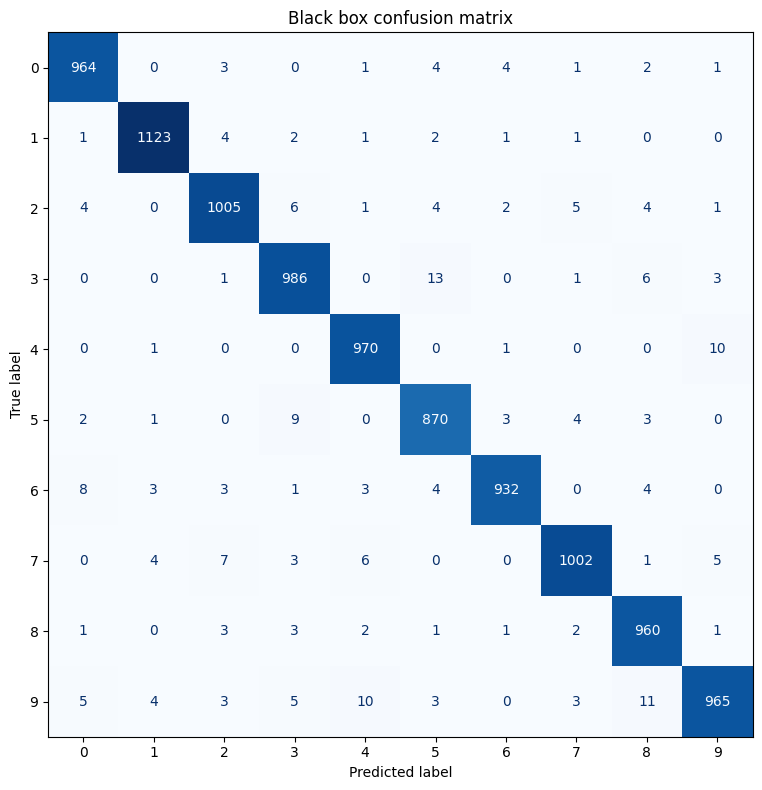

In [13]:
figure, axes = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_black, ax=axes,
                                        cmap="Blues", colorbar=False)
axes.set_title("Black box confusion matrix")
plt.tight_layout()
plt.show()

In [14]:
# the off-diagonal pairs the analysis will focus on
matrix = confusion_matrix(y_test, y_pred_black)
np.fill_diagonal(matrix, 0)

print(f"{'true':<8}{'predicted':<12}{'count':>6}")
for true_label, predicted_label in zip(*np.unravel_index(np.argsort(matrix, axis=None)[::-1][:8],
                                                         matrix.shape)):
    print(f"{true_label:<8}{predicted_label:<12}{matrix[true_label, predicted_label]:>6}")

true    predicted    count
3       5               13
9       8               11
4       9               10
9       4               10
5       3                9
6       0                8
7       2                7
3       8                6


The confusions are structured, not random. 5 and 3 account for 29 errors in both
directions, then 4 mistaken for 9 eleven times, and 9 scattered over 8, 7 and 4.

These pairs share the discriminative region: 3 and 5 have the same lower belly
and differ in the upper stroke, a horizontal bar against a closed arc. The
saliency maps should show whether the model looks at the part that separates
them or at the part they have in common.

In [15]:
# two groups to compare: confident correct predictions, and the 3/5 confusions
correct = np.flatnonzero(y_pred_black == y_test)
confident_correct = correct[np.argsort(confidence_black[correct])[::-1][:20]]

is_three_five = np.isin(y_test, [3, 5]) & np.isin(y_pred_black, [3, 5])
errors_three_five = np.flatnonzero(is_three_five & (y_pred_black != y_test))
correct_three_five = np.flatnonzero(is_three_five & (y_pred_black == y_test))[:len(errors_three_five)]


print(f"{'confident correct:':<22}{len(confident_correct):>5}")
print(f"{'3/5 errors:':<22}{len(errors_three_five):>5}")

confident correct:       20
3/5 errors:              22


## 4. Helpers

Six techniques applied to dozens of images: each one gets a function with the
same signature (image, target class) returning a 28x28 map, so they are
interchangeable in the plots below.

The attributions are computed at 224x224, the size the network works at, then
downsampled to 28x28 to overlay on the original digit.

In [16]:
def get_image(index):
    """The 224x224 input tensor and the original 28x28 digit, for one test image."""
    image, _ = test_set[index]
    return image.unsqueeze(0).to(DEVICE), test_set.data[index].numpy()


image_tensor, digit = get_image(errors_three_five[0])
print(f"{'tensor shape:':<16}{tuple(image_tensor.shape)}")
print(f"{'digit shape:':<16}{digit.shape}")
print(f"{'true / predicted:':<16}{y_test[errors_three_five[0]]} / {y_pred_black[errors_three_five[0]]}")

tensor shape:   (1, 3, 224, 224)
digit shape:    (28, 28)
true / predicted:3 / 5


In [17]:
def to_map(attribution):
    """Sum over channels, resize to 28x28, scale to [-1, 1] by the map's own peak."""
    heatmap = attribution.squeeze(0).sum(dim=0, keepdim=True)
    heatmap = nn.functional.interpolate(heatmap.unsqueeze(0), size=(28, 28),
                                        mode="bilinear", align_corners=False)
    heatmap = heatmap.squeeze().detach().cpu().numpy()
    return heatmap / (np.abs(heatmap).max() + 1e-8)


# zero is mid-grey after the ImageNet normalisation: MNIST's black background
# sits well below it, one value per channel
mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
BLACK = ((0 - mean) / std).to(DEVICE)

print(f"{'black in normalised space:':<30}{BLACK.flatten().tolist()}")

black in normalised space:    [-2.1179039478302, -2.0357141494750977, -1.804444432258606]


In [18]:
def stroke_attribution(heatmap, digit, threshold=100):
    """Mean absolute attribution inside the stroke and outside it, same threshold as the contour."""
    stroke = digit > threshold
    return np.abs(heatmap[stroke]).mean(), np.abs(heatmap[~stroke]).mean()

In [19]:
# same signature for all methods: (image tensor, target class) -> 28x28 map
saliency = Saliency(black_box)
integrated_gradients = IntegratedGradients(black_box)
occlusion = Occlusion(black_box)

# denseblock4 (7x7) rather than the finer blocks: coarser maps, but the table
# below shows its attribution lands on the stroke more than the alternatives
grad_cam = LayerGradCam(black_box, black_box.features.denseblock4)

def explain_saliency(image_tensor, target):
    return to_map(saliency.attribute(image_tensor, target=target, abs=True))


def explain_integrated_gradients(image_tensor, target):
    return to_map(integrated_gradients.attribute(image_tensor, target=target, n_steps=50))


def explain_occlusion(image_tensor, target):
    return to_map(occlusion.attribute(image_tensor, target=target, baselines=BLACK,
                                      sliding_window_shapes=(3, 32, 32), strides=(3, 16, 16)))


def explain_grad_cam(image_tensor, target):
    return to_map(grad_cam.attribute(image_tensor, target=target))

In [20]:
# the Grad-CAM layer is a choice: deeper blocks give coarser maps, so check
# where the attribution actually lands before picking one
layers = [("denseblock2", black_box.features.denseblock2),
          ("denseblock3", black_box.features.denseblock3),
          ("denseblock4", black_box.features.denseblock4)]

print(f"{'layer':<16}{'inside':>10}{'outside':>10}{'ratio':>10}")
for name, layer in layers:
    explainer = LayerGradCam(black_box, layer)
    ratios = []
    for index in confident_correct:
        image_tensor, digit = get_image(index)
        heatmap = to_map(explainer.attribute(image_tensor, target=int(y_pred_black[index])))
        ratios.append(stroke_attribution(heatmap, digit))

    inside, outside = np.mean(ratios, axis=0)
    print(f"{name:<16}{inside:>10.3f}{outside:>10.3f}{inside / outside:>10.1f}")

layer               inside   outside     ratio
denseblock2          0.294     0.236       1.2
denseblock3          0.367     0.257       1.4
denseblock4          0.590     0.338       1.7


In [21]:
image_tensor, digit = get_image(errors_three_five[0])
target = int(y_pred_black[errors_three_five[0]])

for name, method in [("saliency", explain_saliency),
                     ("integrated gradients", explain_integrated_gradients),
                     ("occlusion", explain_occlusion),
                     ("grad-cam", explain_grad_cam)]:
    heatmap = method(image_tensor, target)
    print(f"{name:<24}{str(heatmap.shape):<10}{heatmap.min():>7.2f}{heatmap.max():>7.2f}")

saliency                (28, 28)     0.00   1.00
integrated gradients    (28, 28)    -0.80   1.00
occlusion               (28, 28)    -0.04   1.00
grad-cam                (28, 28)    -0.00   1.00


In [22]:
# GradientShap needs a baseline distribution: black images plus noise
generator = torch.Generator().manual_seed(SEED)
noise = torch.randn(4, 3, 224, 224, generator=generator) * 0.1

gradient_shap = GradientShap(black_box)
shap_baseline = torch.cat([
    BLACK.expand(1, 3, 224, 224),
    BLACK + noise.to(DEVICE),
])


def explain_shap(image_tensor, target):
    torch.manual_seed(SEED)  # GradientShap resamples its baseline at every call
    return to_map(gradient_shap.attribute(image_tensor, baselines=shap_baseline,
                                          target=target, n_samples=20))

In [23]:
# LIME works on RGB numpy images and needs a predict function on batches
lime_explainer = LimeImageExplainer(random_state=SEED)


def lime_predict(images):
    batch = torch.tensor(images, dtype=torch.float32).permute(0, 3, 1, 2)
    with torch.no_grad():
        return black_box(batch.to(DEVICE)).softmax(dim=1).cpu().numpy()


def explain_lime(image_tensor, target, num_samples=200):
    image = image_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
    explanation = lime_explainer.explain_instance(image.astype(np.double), lime_predict,
                                                  labels=(target,), num_samples=num_samples,
                                                  hide_color=0)
    _, mask = explanation.get_image_and_mask(target, positive_only=False, num_features=5)
    # to_map expects (1, C, H, W): the mask is a single-channel 224x224 image
    heatmap = torch.tensor(mask, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    return to_map(heatmap)

In [24]:
for name, method in [("shap", explain_shap), ("lime", explain_lime)]:
    heatmap = method(image_tensor, target)
    print(f"{name:<24}{str(heatmap.shape):<10}{heatmap.min():>7.2f}{heatmap.max():>7.2f}")

shap                    (28, 28)    -0.87   1.00


  0%|          | 0/200 [00:00<?, ?it/s]

lime                    (28, 28)     0.00   1.00


In [25]:
METHODS = [
    ("saliency", explain_saliency),
    ("integrated gradients", explain_integrated_gradients),
    ("occlusion", explain_occlusion),
    ("grad-cam", explain_grad_cam),
    ("shap", explain_shap),
    ("lime", explain_lime),
]


def plot_explanations(index, target, title):
    """The digit plus one map per technique, overlaid on the image."""
    image_tensor, digit = get_image(index)

    figure, axes = plt.subplots(1, len(METHODS) + 1, figsize=(16, 3))
    axes[0].imshow(digit, cmap="gray")
    axes[0].set_title("input", fontsize=9)
    axes[0].axis("off")

    for ax, (name, method) in zip(axes[1:], METHODS):
      heatmap = method(image_tensor, target)
      ax.imshow(digit, cmap="gray")
      # fixed scale: to_map already normalised each map by its own peak,
      # rescaling again would make a flat map look like a concentrated one
      image = ax.imshow(heatmap, cmap="RdBu_r", vmin=-1, vmax=1, alpha=0.45)
      ax.contour(digit, levels=[100], colors="black", linewidths=0.5)  # keep the stroke visible
      ax.set_title(name, fontsize=9)
      ax.axis("off")

    figure.colorbar(image, ax=axes, fraction=0.015, label="normalised attribution")
    figure.suptitle(title)
    plt.show()

## 5. A Single Case

In [26]:
# a number under what the maps show: how much attribution lands on the stroke
image_tensor, digit = get_image(index)
target = int(y_pred_black[index])

print(f"{'method':<22}{'inside':>10}{'outside':>10}{'ratio':>10}")
for name, method in METHODS:
    inside, outside = stroke_attribution(method(image_tensor, target), digit)
    print(f"{name:<22}{inside:>10.3f}{outside:>10.3f}{inside / outside:>10.1f}")

method                    inside   outside     ratio
saliency                   0.031     0.093       0.3
integrated gradients       0.076     0.099       0.8
occlusion                  0.682     0.124       5.5
grad-cam                   0.854     0.482       1.8
shap                       0.223     0.007      31.8


  0%|          | 0/200 [00:00<?, ?it/s]

lime                       0.002     0.103       0.0


  0%|          | 0/200 [00:00<?, ?it/s]

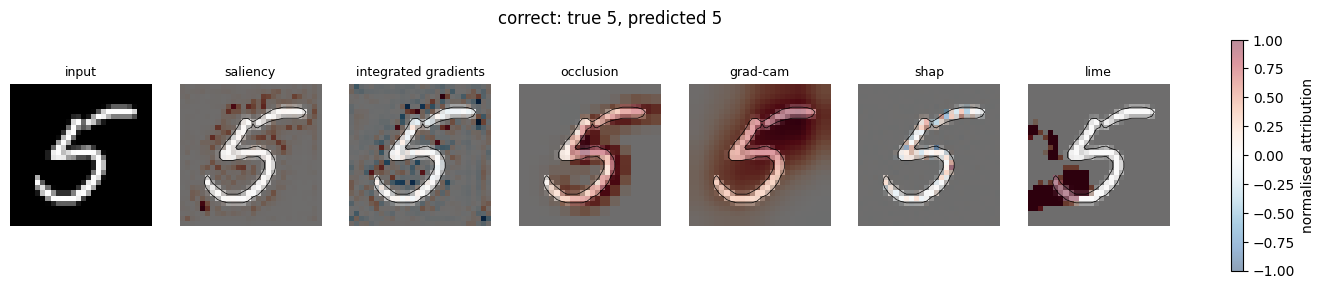

In [27]:
index = confident_correct[0]
plot_explanations(index, int(y_pred_black[index]),
                  f"correct: true {y_test[index]}, predicted {y_pred_black[index]}")

- The six maps agree on the region but differ in granularity: saliency is
  pixel-level and noisy, Grad-CAM is smooth and low-resolution, LIME works on
  superpixels
- The ratio column puts a number on it — mean absolute attribution inside the
  stroke against outside it. SHAP is the most concentrated at 31.8, then
  occlusion at 5.5 and Grad-CAM at 1.8
- Saliency (0.3) and integrated gradients (0.8) spread their attribution as much
  over the background as over the digit, which is the pixel-level noise both
  methods are known for
- LIME sits at 0.0: its mask barely touches the stroke at all. Superpixel
  segmentation has little to work with on a near-binary image, where the black
  background is one large uniform region — a limitation of the method on this
  kind of input rather than a property of the model

## 6. Correct versus Wrong

The same six techniques applied to the 3/5 confusions. For each error the map is
computed twice: once for the class the model chose, and once for the true class.
The first says why it answered what it did, the second what evidence it had for
the right answer and ignored.

  0%|          | 0/200 [00:00<?, ?it/s]

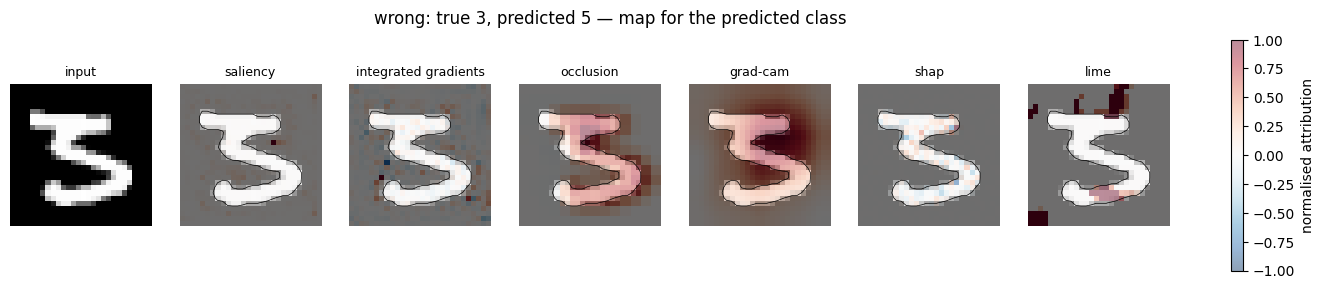

  0%|          | 0/200 [00:00<?, ?it/s]

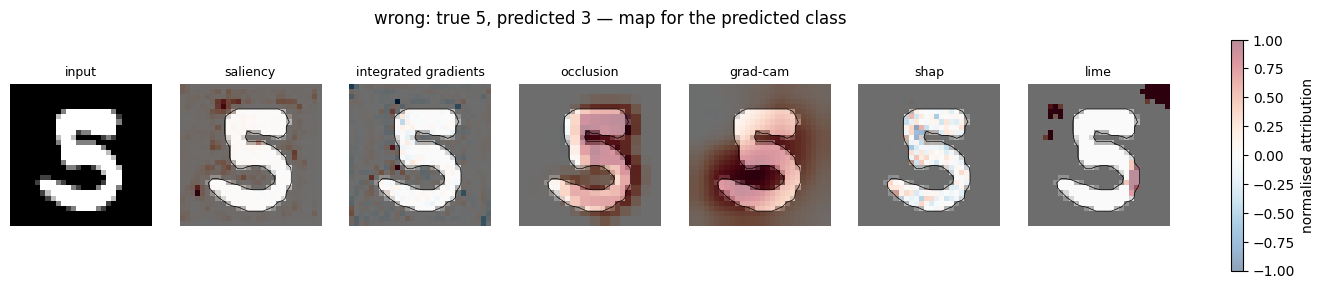

  0%|          | 0/200 [00:00<?, ?it/s]

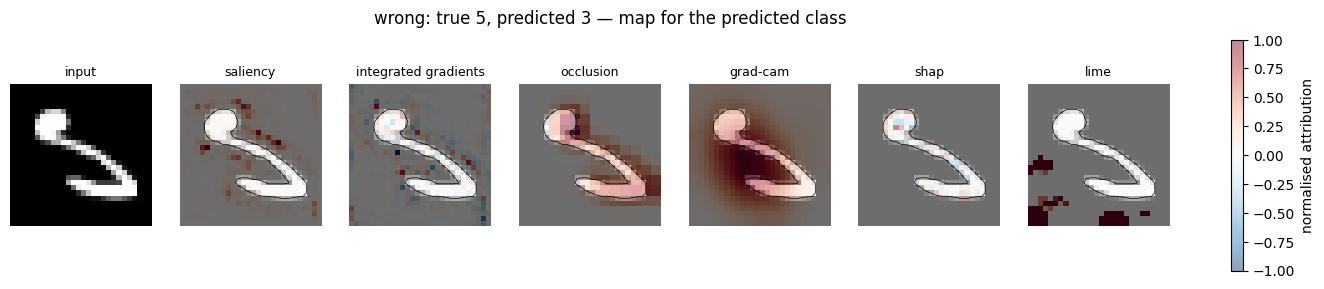

In [28]:
# what the model looked at to produce the wrong answer
for index in errors_three_five[:3]:
    plot_explanations(index, int(y_pred_black[index]),
                      f"wrong: true {y_test[index]}, predicted {y_pred_black[index]}"
                      f" — map for the predicted class")

  0%|          | 0/200 [00:00<?, ?it/s]

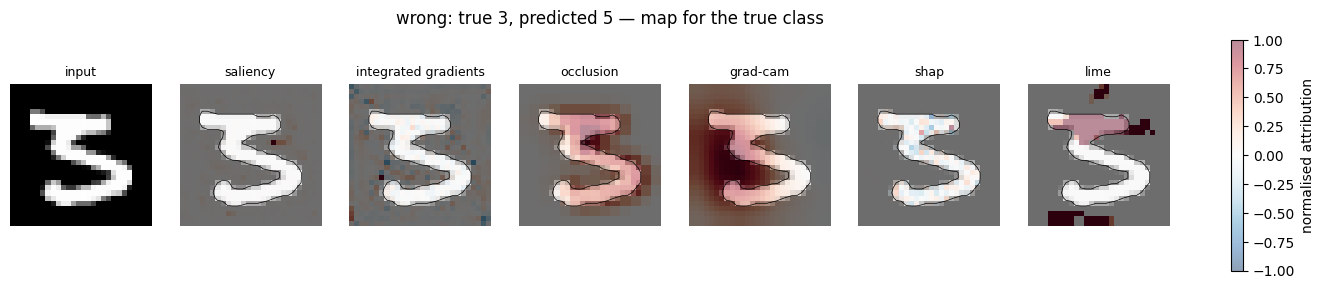

  0%|          | 0/200 [00:00<?, ?it/s]

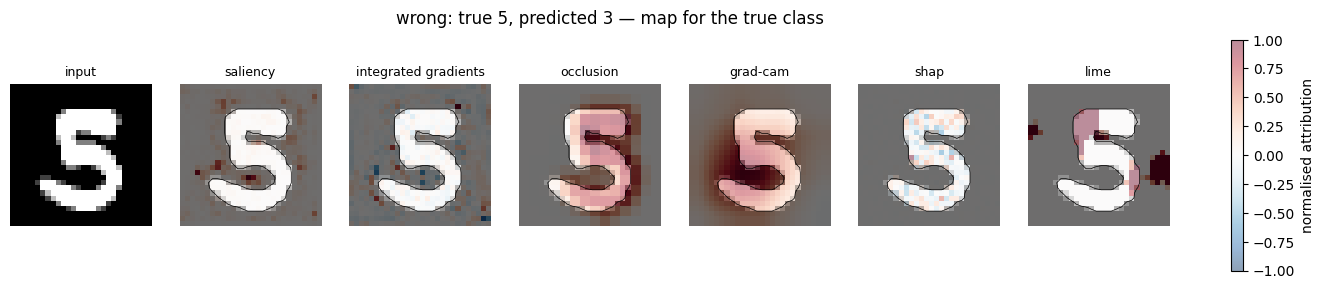

  0%|          | 0/200 [00:00<?, ?it/s]

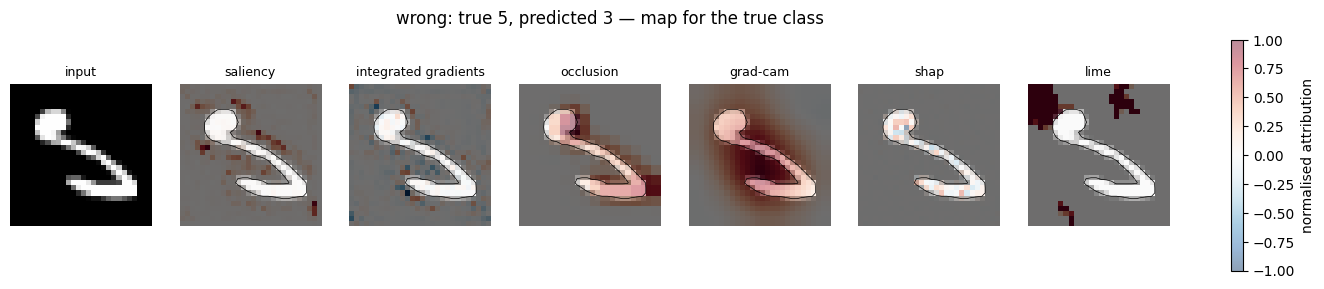

In [29]:
# the evidence for the correct class, on the same images
for index in errors_three_five[:3]:
    plot_explanations(index, int(y_test[index]),
                      f"wrong: true {y_test[index]}, predicted {y_pred_black[index]}"
                      f" — map for the true class")

- Occlusion is the only technique that supports a local reading here. On the 3
read as a 5 the map for the predicted class lights up the top stroke and the
belly, and asking for the true class shifts the weight: the evidence for the
right answer is in the image, weighted differently.

- Grad-CAM does not support that reading, whatever the layer. Computed on 7x7
feature maps and upsampled to 28x28, each of its cells covers about 4x4 pixels of
the digit, so it produces a single blob over the centre rather than structure
along the stroke. Its 1.8 ratio says the blob sits where the digit is, not that
it follows the stroke — MNIST digits are centred by construction, and the metric
cannot tell the two apart.

- SHAP concentrates on the stroke more than anything else (31.8) but scatters
isolated pixels rather than marking regions, and LIME's superpixels are arbitrary
on a digit against a uniform black background. Neither reads as a region-level
explanation.

In [30]:
def mean_map(indices, targets, method=explain_grad_cam):
    """Average map over a group of images, each explained for its own target class."""
    maps = [method(get_image(index)[0], int(target))
            for index, target in tqdm(list(zip(indices, targets)), desc="maps")]
    return np.mean(maps, axis=0)

In [31]:
map_errors = mean_map(errors_three_five, y_pred_black[errors_three_five])
map_correct = mean_map(correct_three_five, y_pred_black[correct_three_five])

maps:   0%|          | 0/22 [00:00<?, ?it/s]

maps:   0%|          | 0/22 [00:00<?, ?it/s]

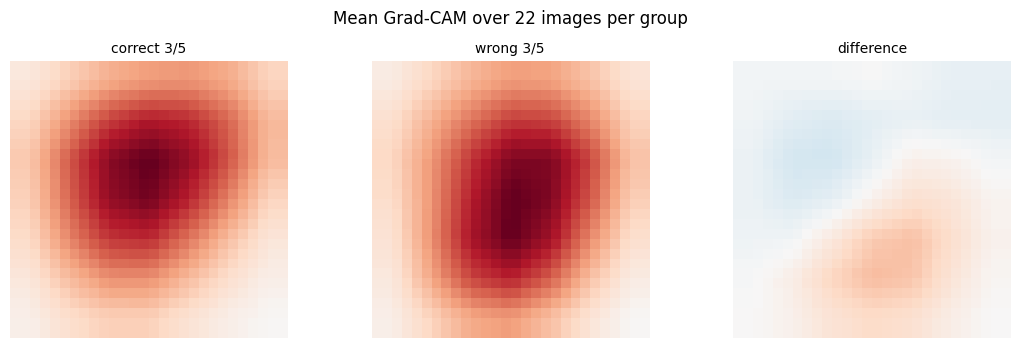

In [32]:
figure, axes = plt.subplots(1, 3, figsize=(11, 3.5))
scale = max(np.abs(map_errors).max(), np.abs(map_correct).max())

for ax, heatmap, title in zip(axes,
                              [map_correct, map_errors, map_errors - map_correct],
                              ["correct 3/5", "wrong 3/5", "difference"]):
    ax.imshow(heatmap, cmap="RdBu_r", vmin=-scale, vmax=scale)
    ax.set_title(title, fontsize=10)
    ax.axis("off")

figure.suptitle(f"Mean Grad-CAM over {len(errors_three_five)} images per group")
plt.tight_layout()
plt.show()

In [33]:
# the same comparison as the maps above, as a number instead of a colour
groups = [
    ("correct 3/5", correct_three_five, "predicted"),
    ("wrong, predicted class", errors_three_five, "predicted"),
    ("wrong, true class", errors_three_five, "true"),
]

print(f"{'group':<26}{'inside':>10}{'outside':>10}{'ratio':>10}")
for name, indices, target_kind in groups:
    ratios = []
    for index in indices:
        image_tensor, digit = get_image(index)
        target = int(y_pred_black[index]) if target_kind == "predicted" else int(y_test[index])
        inside, outside = stroke_attribution(explain_grad_cam(image_tensor, target), digit)
        ratios.append((inside, outside))

    inside, outside = np.mean(ratios, axis=0)
    print(f"{name:<26}{inside:>10.3f}{outside:>10.3f}{inside / outside:>10.1f}")

group                         inside   outside     ratio
correct 3/5                    0.583     0.331       1.8
wrong, predicted class         0.637     0.338       1.9
wrong, true class              0.540     0.315       1.7


The mean maps invite a reading, but the numbers do not support one: the
inside/outside ratio is 1.8 for correct 3/5 predictions, 1.9 for the wrong ones
explained on the predicted class, and 1.7 on the true class.

Whatever separates a correct prediction from a wrong one here, mean Grad-CAM
attribution over the stroke does not capture it. That is worth stating rather
than working around — a coloured map always suggests a story, and this is the
check that decides whether the story holds.

## 7. Explainer Stability

LIME is the only one of the six with a random component: it samples a cloud of
perturbed images and fits a linear model on it, so two runs on the same image
can disagree. The other five are deterministic.

Running it three times on an easy image and on one of the 3/5 errors tests the
first requirement of a good explainer — consistent explanations on the same
input — and, where it fails, says something about the model rather than about
LIME.

In [34]:
def plot_lime_runs(index, title, runs=3):
    """The same image explained three times: LIME resamples at every call."""
    image_tensor, digit = get_image(index)
    target = int(y_pred_black[index])

    figure, axes = plt.subplots(1, runs + 1, figsize=(11, 3))
    axes[0].imshow(digit, cmap="gray")
    axes[0].set_title("input", fontsize=9)
    axes[0].axis("off")

    for run, ax in enumerate(axes[1:]):
        heatmap = explain_lime(image_tensor, target, num_samples=1000)
        ax.imshow(digit, cmap="gray")
        ax.imshow(heatmap, cmap="RdBu_r", vmin=-1, vmax=1, alpha=0.45)
        ax.contour(digit, levels=[100], colors="black", linewidths=0.5)
        ax.set_title(f"run {run + 1}", fontsize=9)
        ax.axis("off")

    figure.suptitle(title)
    plt.tight_layout()
    plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

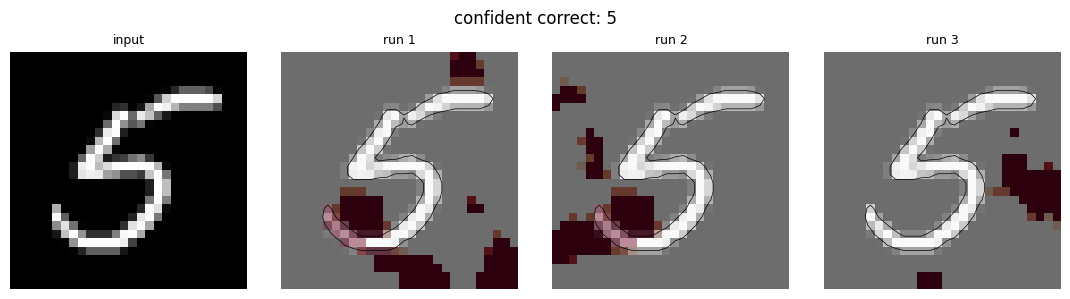

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

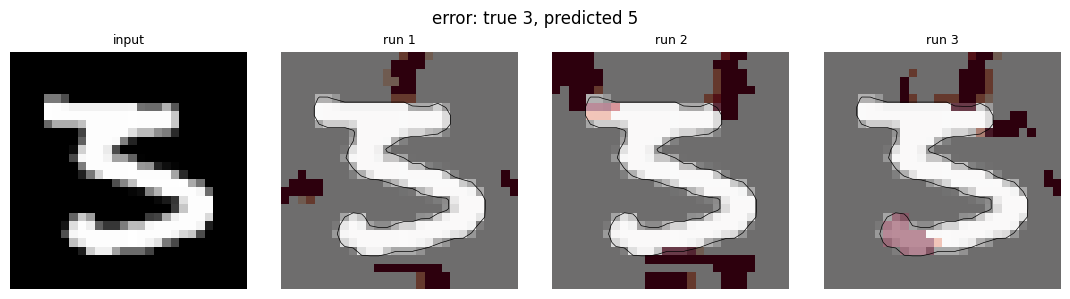

In [35]:
index_easy = confident_correct[0]
plot_lime_runs(index_easy, f"confident correct: {y_test[index_easy]}")

index_hard = errors_three_five[0]
plot_lime_runs(index_hard, f"error: true {y_test[index_hard]}, "
                           f"predicted {y_pred_black[index_hard]}")

- On the confident 5 the three runs share a core: the lower loop and the area to
its upper right come up every time.

- On the error nothing recurs, and one run finds almost nothing on the digit at
all.

- The instability is information about the model, not a flaw in LIME. This image
sits near the 3/5 boundary, so different perturbations push the output different
ways — consistent with the model getting it wrong.

- Raising `num_samples` to 1000 does not tighten the maps much. The limit is the
superpixel segmentation: quickshift is built for natural photographs and on a
digit against a black background it produces large, arbitrary segments, mostly
of background. This is what makes LIME the weakest of the six here.

## 8. Glass Box versus Black Box

The linear model showed its reasoning in ten coefficient maps, valid for every
image at once. The black box needed six techniques to say something about one
image at a time, and only two of them were readable.

Here the same digits are put through both, side by side.

In [36]:
def explain_glass_box(index, target):
    """Coefficient times pixel value: the local explanation of a linear model."""
    return glass_box.coef_[target].reshape(28, 28) * X_test[index].reshape(28, 28)

In [37]:
def plot_comparison(index, title):
    """The digit, the glass box local explanation, and Grad-CAM on the black box."""
    predicted = int(y_pred_black[index])
    image_tensor, digit = get_image(index)

    glass_map = explain_glass_box(index, predicted)
    glass_map = glass_map / (np.abs(glass_map).max() + 1e-8)  # same scaling as to_map

    panels = [
        (digit, "gray", "input"),
        (glass_map, "RdBu_r", "glass box: coef x pixel"),
        (explain_grad_cam(image_tensor, predicted), "RdBu_r", "black box: grad-cam"),
    ]

    figure, axes = plt.subplots(1, 3, figsize=(9, 3.2))
    for ax, (heatmap, cmap, name) in zip(axes, panels):
        if cmap == "gray":
            ax.imshow(heatmap, cmap=cmap)
        else:
            image = ax.imshow(heatmap, cmap=cmap, vmin=-1, vmax=1)
        ax.set_title(name, fontsize=9)
        ax.axis("off")

    figure.colorbar(image, ax=axes, fraction=0.03, label="normalised attribution")
    figure.suptitle(title)
    plt.show()

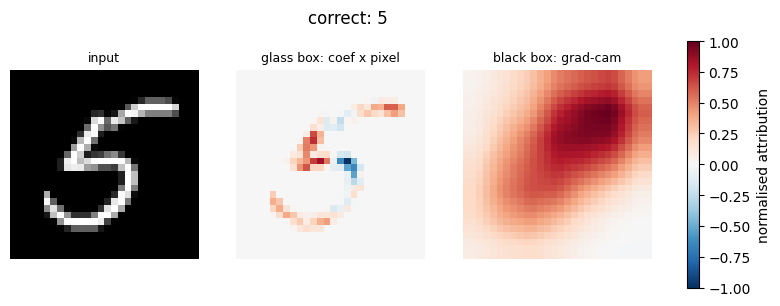

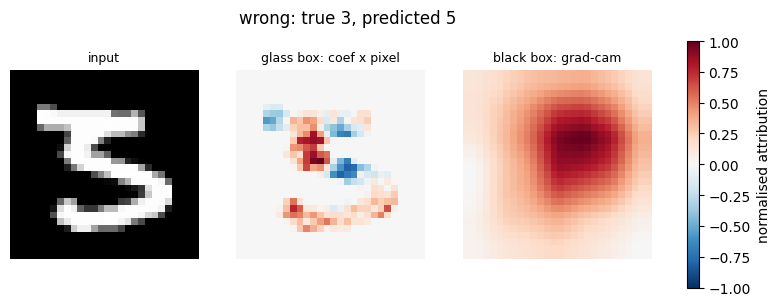

In [38]:
plot_comparison(confident_correct[0],
                f"correct: {y_test[confident_correct[0]]}")
plot_comparison(errors_three_five[0],
                f"wrong: true {y_test[errors_three_five[0]]}, "
                f"predicted {y_pred_black[errors_three_five[0]]}")

The two explanations are not the same kind of object.

- The glass box attributes only on the stroke, because `coef x pixel` is zero
where the pixel is black. The values are readable and additive: they sum back to
the prediction.

- Grad-CAM covers the whole image, background included, and returns a region. It
says where the model looked, not how much each pixel contributed.

- On the misclassified 5 the linear model marks the lower part as evidence
against the class, while Grad-CAM's blob drifts towards the centre and bottom —
the same shift the aggregate showed.

The black box buys 5.9 accuracy points and pays for them with this: ten global
maps replaced by six local techniques, of which one gives a region-level reading.

## 9. Conclusions

- **The black box is justified, but barely explained.** 97.79% against 91.89% for
the logistic regression: 5.9 points bought at the price of ten readable global
maps replaced by six local techniques, of which one gives a region-level reading.

- **The 3/5 errors look like they come from the upper stroke, but that is not
measured.** On single cases the occlusion maps shift when you ask for the true
class instead of the predicted one. Aggregated over the 22 errors the
inside/outside ratio does not separate correct from wrong predictions at all —
1.8 against 1.9. The single-case reading stays a hypothesis.

- **Occlusion is the only technique that works here.** Ratio 5.5, and maps that
change when the target changes. SHAP is the most concentrated of all (31.8) but
marks scattered pixels rather than regions; Grad-CAM returns one blob, since 7x7
feature maps cannot resolve parts of a 28x28 digit; saliency and integrated
gradients spread over the background; LIME's superpixels are built for natural
photographs. Choosing the explainer is a choice about the data type as much as
about the method.

- **Measuring the maps changed the conclusions.** Mean attribution inside the
stroke against outside it exposed a baseline bug — occlusion was reading the
background, because zero is mid-grey after ImageNet normalisation, not black —
and it settled the Grad-CAM layer, where the deepest block scores higher than the
finer ones. Both were invisible in the figures.

- **LIME's instability is a diagnostic.** Three runs agree on a confident
prediction and disagree completely on a misclassified one. The explainer is not
failing: it is reporting that the model has no decisive region on that image.

- **The glass box explains itself.** Its coefficients are the model, not an
approximation of it, and they are additive: they sum back to the prediction. The
black box only ever gets a region and a direction. For a bank that has to justify
a decision, that difference is the whole point.

- **What is missing.** The debugging loop stops at diagnosis. The natural next
step is occlusion-based augmentation — the XAI technique turned into a training
technique — retraining, and measuring whether the 3/5 confusions drop.